# Régression linéaire avec Pytorch

Dans ce notebook, nous allons apprendre à utiliser Pytorch pour entraîner un modèle de régression linéaire sur le jeu de données Boston de Scikit-learn.

L'objectif est de prédire le prix des maisons à partir de leurs caractéristiques.

## Importation des packages

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torchsummary import summary

In [7]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1445633257.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


## Importation des données

In [8]:
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target =raw_df.values[1::2, 2]

Séparation du jeu d'entraînement et du jeu de test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.33, random_state=42)

Normalisation du jeu de données

In [10]:
std_scaler = StandardScaler().fit(X_train, y_train)

X_train  =  std_scaler.transform(X_train)
X_test = std_scaler.transform(X_test)

Passage de Numpy à Pytorch

In [11]:
x_train_torch = torch.from_numpy(X_train).to(torch.float32)
x_test_torch = torch.from_numpy(X_test).to(torch.float32)

y_train_torch = torch.from_numpy(y_train.reshape(-1, 1)).to(torch.float32)
y_test_torch = torch.from_numpy(y_test.reshape(-1, 1)).to(torch.float32)

## Création de l'architecture

La fonction `Linear` permet d'initialiser les poids pour la régression linéaire et d'effectuer une multiplication matricielle entre les poids et les exemples d'entraînement. Utilisez les paramètres `in_features` et `out_features` pour spécifier le nombre d'entrées et de sorties de la couche.

Pour plus d'informatons, n'hésitez pas à lire la [documentation](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html).

La fonction `Linear` sera déclarée dans un modèle via la fonction `Sequential`.

Pour plus d'informatons, n'hésitez pas à lire la [documentation](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html).


In [12]:
def linear_regression(input_shape:int, output_shape:int)->torch.nn.Sequential:
  """
  Creates a simple linear regression model in PyTorch.

  This function initializes a linear regression model with a single linear layer.
  The linear layer applies an affine transformation to the input data, mapping
  from an input space of dimension `input_shape` to an output space of dimension `output_shape`.

  Args:
      input_shape (int): Number of input features (size of the input layer).
      output_shape (int): Number of desired outputs (size of the output layer).

  Returns:
      torch.nn.Sequential: A PyTorch model containing the specified linear layer.
  """
  model = torch.nn.Sequential(torch.nn.Linear(in_features=input_shape, out_features=output_shape))
  return model

Initialiser notre modèle en utilisant la fonction précédente `linear_regression`

In [13]:
rl_model = linear_regression(input_shape=13, output_shape=1)

Utilisez la fonction `print` pour visualiser l'architecture du modèle.

In [14]:
print(rl_model)

Sequential(
  (0): Linear(in_features=13, out_features=1, bias=True)
)


Utilisez la fonction `summary` pour obtenir une visualisation de meilleur qualité.

Aidez-vous de la [doc](https://pypi.org/project/torch-summary/)

In [15]:
summary(rl_model, (13,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 1]              14
Total params: 14
Trainable params: 14
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


Prédire notre jeu d'entraînement.

Utilisez la méthode `forward` du modèle `rl_model` sur les données `x_train_torch` pour appliquer le modèle sur les données.

In [16]:
prediction = rl_model.forward(x_train_torch)

## Définir la fonction de coût

Vous allez maintenant initialiser votre fonction de coût.

Pour ce notebook utilisez la mean absolute error qui a pour nom `L1Loss` en Pytorch.

N'hésitez pas à lire la [documentation](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html).

In [17]:
criterion = torch.nn.L1Loss()

Appliquez la fonction de coût du nom de `criterion` pour comparer les données prédites par notre modèle `prediction` et les valeurs exactes `y_train_torch`.

In [18]:
loss = criterion(prediction, y_train_torch)

### Calculer les gradients

Vous allez calculer les gradients par rapport à l’erreur pour mettre à jour les poids du modèle.

L’objectif est d’ajuster les poids afin de faire converger l’erreur vers 0.

La fonction `backward` de PyTorch permet de calculer automatiquement les gradients qu'importe le graph de calcul que vous avez créé.

Imaginons une matrice de paramètres *w_1* qui va être multiplier par les données *x_1*.

On spécifie bien `requires_grad=True` pour les paramètres.

In [19]:
w_1 = torch.randn([2, 1], dtype=float, requires_grad=True)
x_1 = torch.randn([5, 2], dtype=float)
y = torch.randn([5, 1], dtype=float)

h = torch.mm(x_1, w_1)
print(h.shape)

torch.Size([5, 1])


Calculons l'erreur de prédiction qui est l'écart entre *y* et *h*.

In [20]:
error = torch.mean(h-y)
print(error)

tensor(-1.5472, dtype=torch.float64, grad_fn=<MeanBackward0>)


On va maintenant calculer les gradients des poids *w_1*

In [21]:
print(w_1.grad)
error.backward()
print(w_1.grad)

None
tensor([[-0.4182],
        [ 0.6235]], dtype=torch.float64)


On peut voir que les gradients on été initiliasé à *None*, c'est seulement après l'utilisation de la fonction `backward` que les gradients sont calculés.

Regardons ce que ça donne pour le modèle `rl_model`.

In [22]:
loss

tensor(23.0738, grad_fn=<MeanBackward0>)

On peut voir que la loss caculée précédemment garde des informations sur la fonction de coût et les gradients.

In [23]:
print(rl_model[0].weight.grad)

None


Pour le moment le modèle ne contient aucun gradient.

Utilisez la méthode `backward` du coût `loss` pour calculer les gradients du modèle `rl_model`.

In [24]:
loss.backward()

Observez les gradients ainsi obtenus.

In [25]:
print(rl_model[0].weight.grad)

tensor([[-2.1741e-09, -9.9730e-09,  1.6473e-08,  5.4041e-08, -4.6117e-09,
         -7.3844e-09,  1.4788e-08,  5.2371e-09,  1.3034e-09, -1.4871e-08,
          6.5814e-11,  1.3390e-08,  7.9276e-09]])


### Optimiser les paramètres du modèle

Maintenant que vous avez calculé vos gradients il va falloir mettre à jour les paramètres du modèle.

Il existe de nombreux algorithmes d'optimisation, ici on va rester simple en utilisant celui du Stochastic Gradient Descent `SGD`.

Vous allez d'abord initialiser l'algorithme d'optimisation avec la fonction `SGD` en paramètre il faudra lui donner les paramètres du modèle `rl_model` avec la méthode `parameters` et un learning rate `lr` de 0.3.

N'hésitez pas à regarder la [documentation](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html)

In [26]:
optimizer = torch.optim.SGD(rl_model.parameters(), lr=1)

Regardez les valeurs des paramètres du modèle.

In [27]:
print(rl_model[0].weight)

Parameter containing:
tensor([[-0.2498, -0.1496, -0.0474, -0.1794,  0.0113,  0.1430, -0.1398, -0.2679,
          0.0607, -0.0757, -0.2287, -0.1704, -0.0619]], requires_grad=True)


Regardez les gradients de chaque paramètre.

In [28]:
print(rl_model[0].weight.grad)

tensor([[-2.1741e-09, -9.9730e-09,  1.6473e-08,  5.4041e-08, -4.6117e-09,
         -7.3844e-09,  1.4788e-08,  5.2371e-09,  1.3034e-09, -1.4871e-08,
          6.5814e-11,  1.3390e-08,  7.9276e-09]])


Calculez le coût du modèle à ce stade.

In [29]:
loss

tensor(23.0738, grad_fn=<MeanBackward0>)

Utilisez la méthode `step` de l'algorithme d'optimisation `optimizer` afin de mettre à jour les paramètres du modèle en utilisant l'algorithme du gradient descent en utilisant les gradients précédemment calculé.

In [30]:
optimizer.step()

Regardez les nouvelles valeurs des paramètres du modèle.

In [31]:
print(rl_model[0].weight)

Parameter containing:
tensor([[-0.2498, -0.1496, -0.0474, -0.1794,  0.0113,  0.1430, -0.1398, -0.2679,
          0.0607, -0.0757, -0.2287, -0.1704, -0.0619]], requires_grad=True)


Utilisez la méthode `forward` pour prédire les données avec les nouveaux paramètres du modèle.

In [32]:
prediction = rl_model.forward(x_train_torch)

Utilisez `criterion` pour calculer le coût du modèle avec les nouveaux paramètres.

In [33]:
criterion(prediction, y_train_torch)

tensor(22.0738, grad_fn=<MeanBackward0>)

On observe qu'avec les nouveaux paramètres, le coût est inférieur au précédent.

Le modèle converge donc vers un ensemble de paramètres qui minimise l'erreur de prédiction.

## Définir la fonction d'entraînement

Vous allez maintenant initialiser la fonction d'entraînement du modèle en utilisant le modèle, la fonction de coût et l'algorithme d'optimisation précédemment initialisé.

In [34]:
def step(model:torch.nn.Sequential,
         opt:torch.optim,
         criterion:torch.nn.modules.loss,
         x_train:torch.Tensor,
         y_train:torch.Tensor)->tuple:
  """
  Executes a single training step for a PyTorch model.
  This function performs a forward pass to compute the model's predictions, calculates
  the loss between predictions and actual target values, computes gradients for each
  model parameter, and updates the parameters using the optimizer.

  Args:
      model (torch.nn.Sequential): The PyTorch model to train.
      optimizer (torch.optim.Optimizer): Optimizer used to update the model's parameters.
      criterion (torch.nn.modules.loss._Loss): Loss function used to compute the error.
      x_train (torch.Tensor): Input training data (features).
      y_train (torch.Tensor): Ground truth labels or target values for the training data.
  Returns:
      tuple: The updated model and the computed loss for the current step.
  """

  # Réinitialisez les gradients d'optimizer à zéro avec la méthode 'zero_grad'
  opt.zero_grad()

  # Calculez les prédiction sur le jeu d'entraînement avec la méthode 'forward'
  prediction = model.forward(x_train)

  # Calculez l'erreur de prédiction avec 'criterion'
  loss = criterion(prediction, y_train)

  # Calculez les gradients avec la méthode 'backward'
  loss.backward()

  # Mettre à jour les paramètres du modèle avec la méthode 'step'
  optimizer.step()

  return model, loss

## Entraîner le modèle

Il est maintenant temps d'entraîner le modèle



In [36]:
epoch = 1000
history_train = []
history_test = []

for e in range(epoch) :

  # mise à jour des poids avec la fonction 'step'
  rl_model, train_loss = step(rl_model, optimizer, criterion, x_train_torch, y_train_torch)

  # prédiction sur le jeu de test avec la méthode 'forward'
  test_pred = rl_model.forward(x_test_torch)

  # Calculer l'erreur de prédiction sur le jeu de test avec 'criterion'
  test_loss = criterion(test_pred, y_test_torch)

  # Sauvegarde des coûts d'entraînement de l'entraînement et du jeu de test avec append
  history_train = np.append(history_train, train_loss.detach().numpy())
  history_test = np.append(history_test, test_loss.detach().numpy())

  print('train_loss : '+str(np.squeeze(train_loss.detach().numpy()))+ ' test_loss : '+str(test_loss.detach().numpy()))


train_loss : 21.073769 test_loss : 18.832027
train_loss : 20.073769 test_loss : 17.832027
train_loss : 19.073769 test_loss : 16.832027
train_loss : 18.07377 test_loss : 15.832028
train_loss : 17.07377 test_loss : 14.836399
train_loss : 16.077438 test_loss : 13.869058
train_loss : 15.10467 test_loss : 12.926233
train_loss : 14.147817 test_loss : 11.992606
train_loss : 13.198508 test_loss : 11.064229
train_loss : 12.253494 test_loss : 10.14293
train_loss : 11.312336 test_loss : 9.229835
train_loss : 10.382161 test_loss : 8.31674
train_loss : 9.451984 test_loss : 7.4198084
train_loss : 8.530456 test_loss : 6.5675883
train_loss : 7.6663313 test_loss : 5.865201
train_loss : 6.9070754 test_loss : 5.2354574
train_loss : 6.1958456 test_loss : 4.674759
train_loss : 5.5782523 test_loss : 4.2378864
train_loss : 5.040261 test_loss : 3.949273
train_loss : 4.604256 test_loss : 3.7227082
train_loss : 4.2863274 test_loss : 3.5667436
train_loss : 4.036355 test_loss : 3.4272144
train_loss : 3.8380013 te

Visualisation de l'évolution du coût pendant l'entraînement.

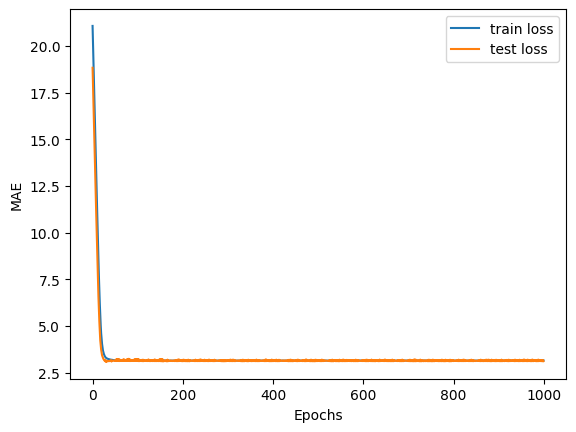

In [37]:
plt.plot(np.arange(epoch), history_train, label='train loss')
plt.plot(np.arange(epoch), history_test, label='test loss')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

## Sauvegarde du modèle

Maintenant que le modèle est entraîné, il est temps de le sauvegarder.

Sauvegardez les poids du modèle grâce à la méthode `save`.

N'hésitez pas à vous aider de la [documentation](https://pytorch.org/tutorials/beginner/saving_loading_models.html)

In [38]:
torch.save(rl_model.state_dict(), 'linear_regression.pth')

Remplacez le modèle entraîné par un nouveau modèle dont les poids sont initialisés aléatoirement.

In [39]:
rl_model = linear_regression(input_shape=13, output_shape=1)

Calculez la performance de ce modèle.

In [40]:
prediction = rl_model(x_train_torch)
criterion(prediction, y_train_torch)

tensor(22.9999, grad_fn=<MeanBackward0>)

Comme les paramètres du modèle sont initialisés aléatoirement, les performances sont faibles.

Nous pouvons restaurer nos poids entraînés en chargeant les poids précédemment sauvegardés.

En utilisant la méthode `load_state_dict`.

Aidez-vous de la [documentation](https://pytorch.org/tutorials/beginner/saving_loading_models.html)

In [41]:
rl_model.load_state_dict(torch.load('linear_regression.pth', weights_only=True))

<All keys matched successfully>

In [42]:
prediction = rl_model.forward(x_train_torch)
criterion(prediction, y_train_torch)

tensor(3.1477, grad_fn=<MeanBackward0>)

Maintenant que les paramètres du modèle entraîné sont chargés, ses performances sont identiques au précédent modèle.